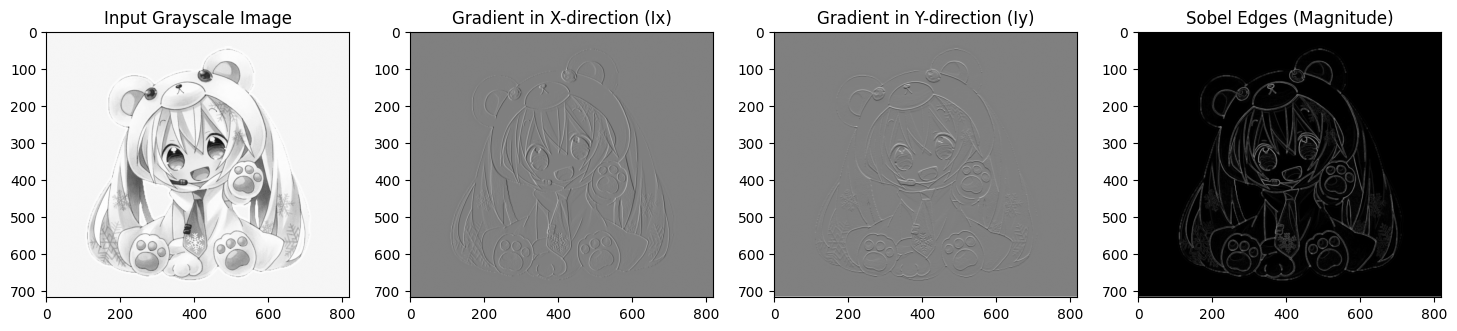

In [7]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from skimage.color import rgb2gray

def sobel_edge_detection(image):
    # Sobel kernels
    sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
    sy = np.array([[-1, -2, -1],
                   [0, 0, 0],
                   [1, 2, 1]])

    Ix = ndimage.convolve(image, sx, mode='constant')
    Iy = ndimage.convolve(image, sy, mode='constant')

    magnitude = np.hypot(Ix, Iy)
    return magnitude / magnitude.max(), Ix, Iy  # Normalize magnitude to 0-1, return Ix and Iy

# Example usage with anime.png
img_path = '/content/anime.png'
img = imageio.imread(img_path)

# Convert to grayscale if it's a color image
if img.ndim == 3:
    img_gray = rgb2gray(img)
else:
    img_gray = img

edges, Ix, Iy = sobel_edge_detection(img_gray)

plt.figure(figsize=(18, 6)) # Increased figure size to accommodate more plots
plt.subplot(141); plt.imshow(img_gray, cmap='gray'); plt.title("Input Grayscale Image")
plt.subplot(142); plt.imshow(Ix, cmap='gray'); plt.title("Gradient in X-direction (Ix)")
plt.subplot(143); plt.imshow(Iy, cmap='gray'); plt.title("Gradient in Y-direction (Iy)")
plt.subplot(144); plt.imshow(edges, cmap='gray'); plt.title("Sobel Edges (Magnitude)")
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt


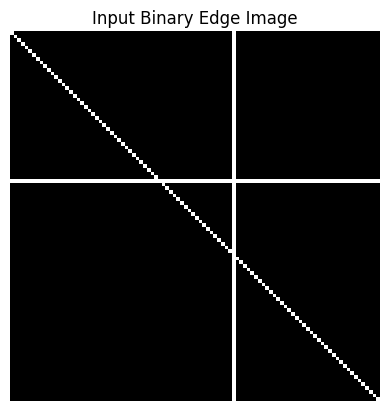

In [23]:
# Create binary edge image
binary_edge = np.zeros((100, 100), dtype=np.uint8)

# Diagonal line
for i in range(100):
    binary_edge[i, i] = 1

# Vertical line
binary_edge[:, 60] = 1

# Horizontal line
binary_edge[40, :] = 1

plt.imshow(binary_edge, cmap='gray')
plt.title("Input Binary Edge Image")
plt.axis('off')
plt.show()


In [24]:
def hough_transform(binary_img, theta_step=1, threshold_ratio=0.6):
    h, w = binary_img.shape
    diag = int(np.ceil(np.hypot(h, w)))

    rhos = np.arange(-diag, diag + 1)
    thetas = np.deg2rad(np.arange(-90, 90, theta_step))

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    y_idxs, x_idxs = np.nonzero(binary_img)

    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    for x, y in zip(x_idxs, y_idxs):
        rho_values = x * cos_t + y * sin_t
        rho_indices = np.round(rho_values + diag).astype(int)
        accumulator[rho_indices, np.arange(len(thetas))] += 1

    threshold = threshold_ratio * accumulator.max()
    peaks = np.argwhere(accumulator >= threshold)

    lines = [(rhos[r], thetas[t]) for r, t in peaks]

    return lines, accumulator


In [25]:
lines, accumulator = hough_transform(binary_edge)

print("Detected lines (ρ, θ in radians):")
for rho, theta in lines:
    print(f"ρ = {rho:.2f}, θ = {theta:.2f}")


Detected lines (ρ, θ in radians):
ρ = -40.00, θ = -1.57
ρ = 0.00, θ = -0.79
ρ = 60.00, θ = 0.00


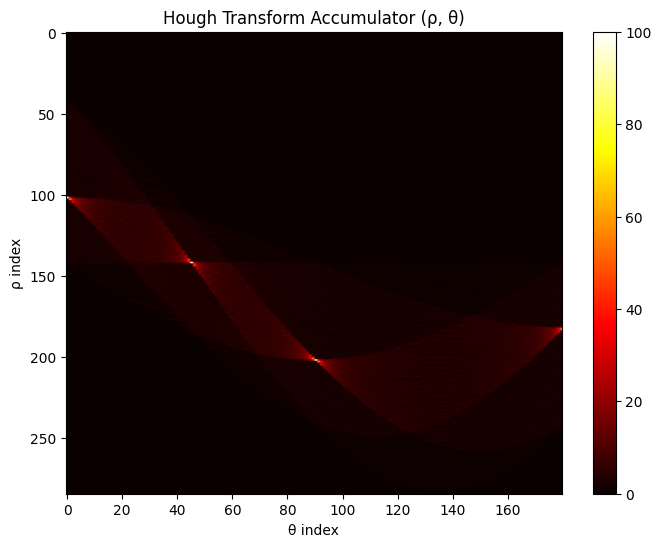

In [26]:
plt.figure(figsize=(8,6))
plt.imshow(accumulator, cmap='hot', aspect='auto')
plt.xlabel("θ index")
plt.ylabel("ρ index")
plt.title("Hough Transform Accumulator (ρ, θ)")
plt.colorbar()
plt.show()


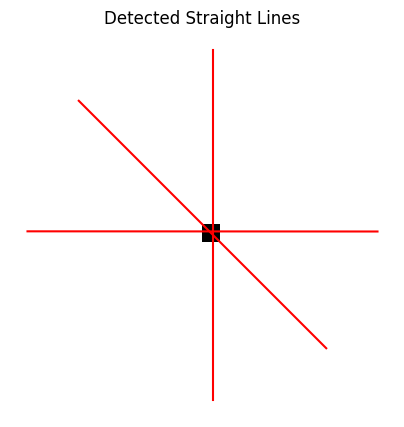

In [27]:
plt.figure(figsize=(5,5))
plt.imshow(binary_edge, cmap='gray')

for rho, theta in lines:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho

    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    plt.plot([x1, x2], [y1, y2], 'r')

plt.title("Detected Straight Lines")
plt.axis('off')
plt.show()


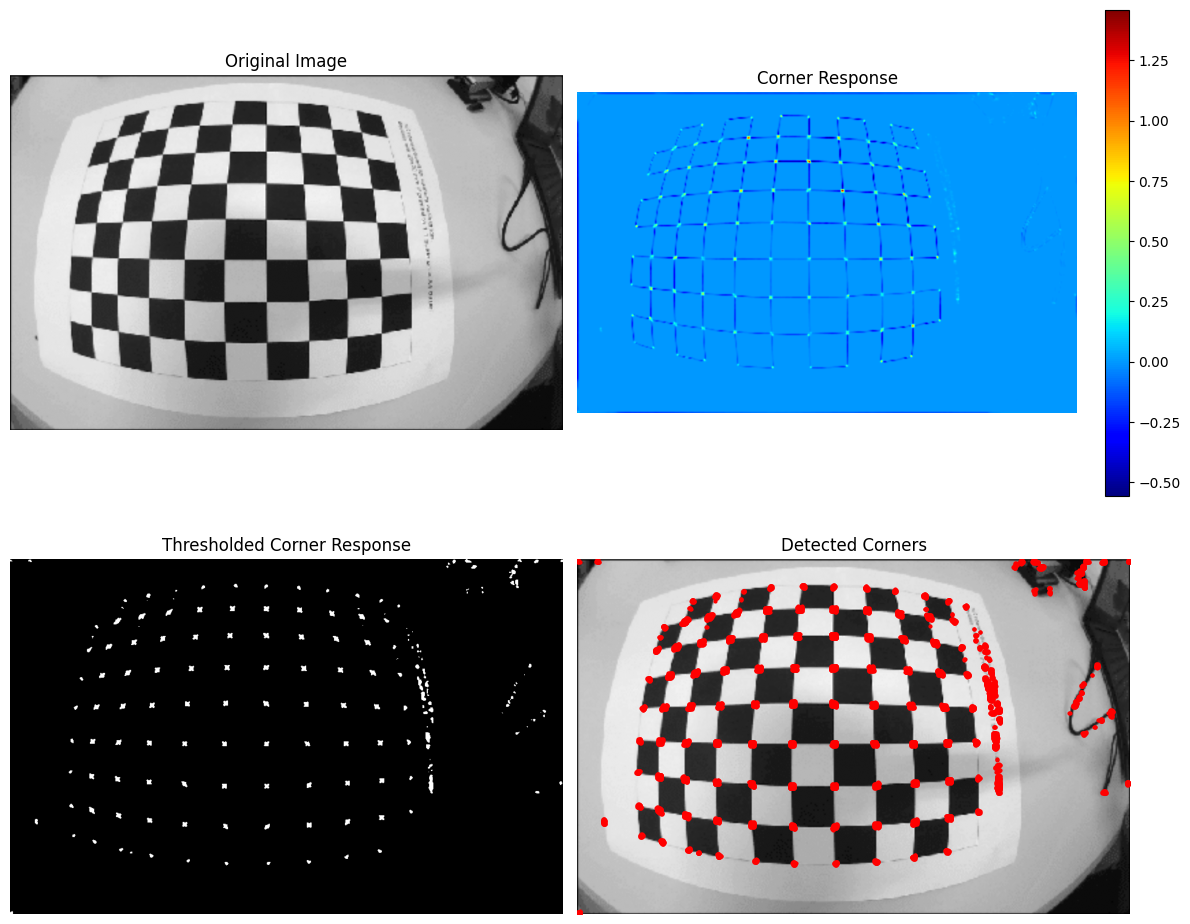

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import io, color

# -------------------------------
# Load image
# -------------------------------
img = io.imread('/content/Screenshot 2026-02-01 172959.png')

# Convert to grayscale
if img.ndim == 3:
    if img.shape[2] == 4: # RGBA image, slice off the alpha channel
        gray = color.rgb2gray(img[:, :, :3])
    elif img.shape[2] == 3: # RGB image
        gray = color.rgb2gray(img)
    else:
        raise ValueError("Unsupported 3D image format for grayscale conversion.")
elif img.ndim == 2:
    gray = img.astype(float)
else:
    raise ValueError("Unsupported image dimension for grayscale conversion.")

# -------------------------------
# Harris Corner Detection
# -------------------------------
def harris_corners(gray, sigma=1.5, k=0.05):
    # Image gradients
    Ix = ndimage.sobel(gray, axis=1)
    Iy = ndimage.sobel(gray, axis=0)

    # Second moment matrix components
    Ix2 = ndimage.gaussian_filter(Ix**2, sigma)
    Iy2 = ndimage.gaussian_filter(Iy**2, sigma)
    Ixy = ndimage.gaussian_filter(Ix * Iy, sigma)

    # Harris response
    det = Ix2 * Iy2 - Ixy**2
    trace = Ix2 + Iy2
    R = det - k * trace**2

    return R

# Compute corner response
R = harris_corners(gray)

# -------------------------------
# Thresholding
# -------------------------------
threshold = 0.01 * R.max()
R_thresh = R > threshold

# Extract corner coordinates
corners = np.argwhere(R_thresh)

# -------------------------------
# Visualization (4 panels)
# -------------------------------
plt.figure(figsize=(12,10))

# Original image
plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Corner response
plt.subplot(2,2,2)
plt.imshow(R, cmap='jet')
plt.title("Corner Response")
plt.axis('off')
plt.colorbar(fraction=0.046)

# Thresholded corner response
plt.subplot(2,2,3)
plt.imshow(R_thresh, cmap='gray')
plt.title("Thresholded Corner Response")
plt.axis('off')

# Detected corners
plt.subplot(2,2,4)
plt.imshow(gray, cmap='gray')
plt.plot(corners[:,1], corners[:,0], 'r.', markersize=4)
plt.title("Detected Corners")
plt.axis('off')

plt.tight_layout()
plt.show()